In [1]:
# Dental Chatbot – Hybrid AI Pipeline
# Model 1: Small-data Intent Classifier
# Model 2: LLM Text Generator

!pip install scikit-learn pandas matplotlib transformers accelerate bitsandbytes torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 15.1 MB/s eta 0:00:00


In [2]:
# STEP 1 – Imports
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import pipeline
import torch


In [3]:
# STEP 2 – Load dataset
df = pd.read_csv("/content/sample_data/dental_multiturn_conversations_225.csv")

print("Dataset loaded successfully!")
print(df.head())
print("\nNumber of examples:", len(df))


Dataset loaded successfully!
   case_id   disease_label     turn_intent  \
0        1  pulpitis_acute  where_location   
1        2  pulpitis_acute        duration   
2        3  pulpitis_acute         trigger   
3        4  pulpitis_acute        severity   
4        5  pulpitis_acute           extra   

                       doctor_question                         patient_answer  
0          Where exactly does it hurt?   The pain is in my lower right molar.  
1    Since when do you feel this pain?        I've had it for about 48 hours.  
2           What makes the pain worse?          Cold drinks cause sharp pain.  
3              How strong is the pain?         It's a throbbing, severe pain.  
4  Is there anything else you noticed?  I also feel some pressure in the jaw.  

Number of examples: 225


In [4]:
# STEP 3 – Prepare data for small-data training (intent classification)
X = df["doctor_question"]
y = df["turn_intent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

print("Classification results:\n")
print(classification_report(y_test, y_pred))


Classification results:

                precision    recall  f1-score   support

      duration       1.00      1.00      1.00         9
         extra       1.00      1.00      1.00         9
      severity       1.00      1.00      1.00         9
       trigger       1.00      1.00      1.00         9
where_location       1.00      1.00      1.00         9

      accuracy                           1.00        45
     macro avg       1.00      1.00      1.00        45
  weighted avg       1.00      1.00      1.00        45



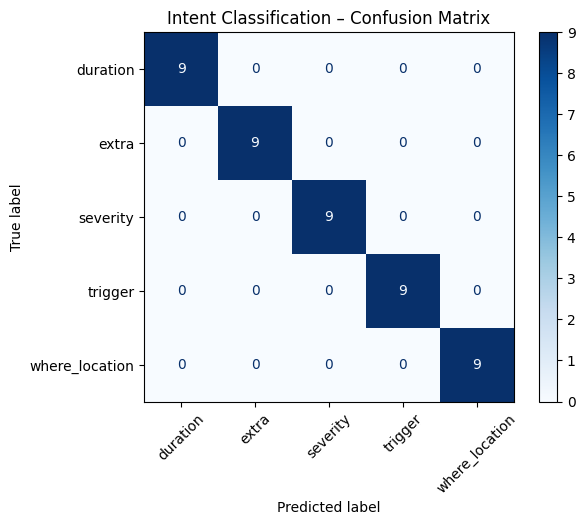

In [5]:
# STEP 4 – Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Intent Classification – Confusion Matrix")
plt.show()

In [6]:
# STEP 5 – Define helper for intent prediction
def classify_intent(question: str):
    vec = vectorizer.transform([question])
    pred = clf.predict(vec)[0]
    return pred

In [9]:
# STEP 6 - Load model
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype="float16"
)
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Device set to use cuda:0


In [12]:
# STEP 7 – Define LLM-based patient response generator

def generate_patient_response(intent, disease="pulpitis_acute"):
    prompt = (
        f"<s>[INST] The dentist asks a patient diagnosed with {disease} "
        f"a question about {intent}. The patient replies briefly (1–2 sentences), "
        "in first person, naturally, as if describing their real symptoms. [/INST]"
    )

    result = generator(
        prompt,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )

    response_text = result[0]["generated_text"]
    clean_text = response_text.split("[/INST]")[-1].strip()
    return clean_text



In [13]:
# STEP 8 – Full conversational pipeline
def dental_chatbot(question, disease="pulpitis_acute"):
    intent = classify_intent(question)
    response = generate_patient_response(intent, disease)
    return {"intent": intent, "response": response}

# Test example conversation
dialogue = [
    "Where exactly does it hurt?",
    "Since when do you feel this pain?",
    "What makes the pain worse?",
    "How strong is the pain?",
    "Is there anything else you noticed?"
]

for q in dialogue:
    result = dental_chatbot(q)
    print(f"Doctor: {q}")
    print(f"Patient ({result['intent']}): {result['response']}\n")


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


👨‍⚕️ Doctor: Where exactly does it hurt?
🤖 Patient (where_location): I'm experiencing a sharp, constant pain in my tooth, especially when I bite down or take hot or cold food or drinks. It's been getting worse over the past few days and keeps me awake at night.



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


👨‍⚕️ Doctor: Since when do you feel this pain?
🤖 Patient (duration): I've been experiencing intense tooth pain for the past few days. It hurts when I apply pressure or eat something cold or hot. The pain keeps me up at night and I can't focus on my daily activities due to the discomfort



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


👨‍⚕️ Doctor: What makes the pain worse?
🤖 Patient (trigger): I feel a sharp, constant pain in my tooth when I take a bite or when I expose it to cold or hot temperatures. The pain can be quite intense and makes it difficult for me to chew on that side of my mouth.



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


👨‍⚕️ Doctor: How strong is the pain?
🤖 Patient (severity): I'm experiencing intense pain in my tooth, especially when I bite down or take hot or cold food or drinks. The pain keeps me awake at night.

👨‍⚕️ Doctor: Is there anything else you noticed?
🤖 Patient (extra): I've been experiencing intense tooth pain, especially when I chew or drink something hot or cold. It feels like a sharp, throbbing sensation deep inside my tooth. Sometimes I even feel a constant ache that keeps me up at night.



In [14]:
def evaluate_diagnosis(true_disease, guessed_disease):
    prompt = f"""
    <s>[INST] You are an intelligent dental assistant.
    The true diagnosis for the patient is: {true_disease}.
    The doctor (student) guessed: {guessed_disease}.

    Compare the two and decide if the guessed diagnosis is correct.
    Respond clearly with one of the following:
    - "Correct diagnosis." if they match.
    - "Incorrect diagnosis." if they don't match.
    Then, in one short sentence, explain why. [/INST]
    """

    result = generator(
        prompt,
        max_new_tokens=60,
        do_sample=False,
        temperature=0.2,
    )

    text = result[0]["generated_text"].split("[/INST]")[-1].strip()
    return text


In [15]:
true_disease = "pulpitis_acute"
guessed_disease = "gingivitis"

print(evaluate_diagnosis(true_disease, guessed_disease))


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


❌ Incorrect diagnosis.
    Gingivitis is an inflammation of the gums, while pulpitis is an inflammation of the pulp tissue inside a tooth.


In [16]:
true_disease = "pulpitis_acute"
guessed_disease = "pulpitis_acute"

print(evaluate_diagnosis(true_disease, guessed_disease))


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


✅ Correct diagnosis.
    The doctor's guess matches the true diagnosis. Both diagnoses indicate an acute inflammation of the pulp tissue inside a tooth.
